In [95]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [96]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings

In [97]:
# from typing import (
#   Any,
#   Iterable,
#   List,
#   Optional,
#   Sequence,
#   Tuple,
#   Union,
# )

# import jax
# import jax.numpy as jnp
# import numpy as np
# from jax import eval_shape, lax
# from jax.core import ShapedArray

# import opt_einsum

# from flax.core import meta
# from flax.linen import initializers
# from flax.linen.dtypes import promote_dtype
# from flax.linen import module
# from flax.linen.module import Module, compact
# from flax.typing import (
#   Array,
#   PRNGKey as PRNGKey,
#   Dtype,
#   Shape as Shape,
#   Initializer,
#   PrecisionLike,
#   DotGeneralT,
#   ConvGeneralDilatedT,
#   PaddingLike,
#   LaxPadding,
# )


# default_kernel_init = initializers.lecun_normal()


# def _normalize_axes(axes: Tuple[int, ...], ndim: int) -> Tuple[int, ...]:
#   # A tuple by convention. len(axes_tuple) then also gives the rank efficiently.
#   return tuple(sorted(ax if ax >= 0 else ndim + ax for ax in axes))


# def _canonicalize_tuple(x: Union[Sequence[int], int]) -> Tuple[int, ...]:
#   if isinstance(x, Iterable):
#     return tuple(x)
#   else:
#     return (x,)

In [98]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [99]:
print(jax.default_backend())

gpu


In [100]:
def Lorenz1960(vals, t):

  A_val, F_val, G_val = vals

  A_t = -(1/(k**2) - 1/(k**2 + l**2))*(k * l * F_val * G_val)
  F_t = (1/(l**2) - 1/(k**2 + l**2))*(k * l * A_val * G_val)
  G_t = -(1/2)*(1/(l**2) - 1/(k**2))*(k * l * A_val * F_val)

  vals_t = [A_t, F_t, G_t]

  return vals_t

In [101]:
t0, tfinal = 0.0, 5.0

In [102]:
k = 1.0
l = 2.0

k_sqr = k**2
l_sqr = l**2

In [103]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [104]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [105]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [106]:
# class DenseMod(nn.Module):
#   """A linear transformation applied over the last dimension of the input.

#   Example usage::

#     >>> import flax.linen as nn
#     >>> import jax, jax.numpy as jnp

#     >>> layer = nn.Dense(features=4)
#     >>> params = layer.init(jax.random.key(0), jnp.ones((1, 3)))
#     >>> jax.tree_util.tree_map(jnp.shape, params)
#     {'params': {'bias': (4,), 'kernel': (3, 4)}}

#   Attributes:
#     features: the number of output features.
#     use_bias: whether to add a bias to the output (default: True).
#     dtype: the dtype of the computation (default: infer from input and params).
#     param_dtype: the dtype passed to parameter initializers (default: float32).
#     precision: numerical precision of the computation see ``jax.lax.Precision``
#       for details.
#     kernel_init: initializer function for the weight matrix.
#     bias_init: initializer function for the bias.
#   """

#   features: int
#   use_bias: bool = True
#   dtype: Optional[Dtype] = None
#   param_dtype: Dtype = jnp.float64
#   precision: PrecisionLike = None
#   kernel_init: Initializer = default_kernel_init
#   bias_init: Initializer = initializers.zeros_init()
#   # Deprecated. Will be removed.
#   dot_general: Optional[DotGeneralT] = None
#   dot_general_cls: Any = None

#   @nn.compact
#   def __call__(self, inputs: Array) -> Array:
#     """Applies a linear transformation to the inputs along the last dimension.

#     Args:
#       inputs: The nd-array to be transformed.

#     Returns:
#       The transformed input.
#     """
#     kernel = self.param(
#       'kernel',
#       self.kernel_init,
#       (jnp.shape(inputs)[-1], self.features),
#       self.param_dtype,
#     )
#     if self.use_bias:
#       bias = self.param(
#         'bias', self.bias_init, (self.features,), self.param_dtype
#       )
#     else:
#       bias = None
#     inputs, kernel, bias = promote_dtype(inputs, kernel, bias, dtype=self.dtype)

#     if self.dot_general_cls is not None:
#       dot_general = self.dot_general_cls()
#     elif self.dot_general is not None:
#       dot_general = self.dot_general
#     else:
#       dot_general = lax.dot_general
#     y = dot_general(
#       inputs,
#       kernel,
#       (((inputs.ndim - 1,), (0,)), ((), ())),
#       precision=self.precision,
#     )
#     if bias is not None:
#       y += jnp.reshape(bias, (1,) * (y.ndim - 1) + (-1,))
#     return y


In [107]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(3*self.units)(b)
    return out

In [108]:
def define_collocation_points(t_bdry, N=100):

  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

  As = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Fs = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Gs = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Es = (1/4)*((As**2/l**2) + (Fs**2/k**2) + (2*(Gs**2)/(k**2 + l**2)))
  Vs = (1/2)*(As**2 + Fs**2 + 2*(Gs**2))

  sensor_points = np.column_stack((As, Fs, Gs, Es, Vs))

  return (ode_points, sensor_points)

In [109]:
(de_points, sensors) = define_collocation_points([t0, tfinal], 1000)
print(de_points.shape, sensors.shape)

(1000, 1) (1000, 5)


In [110]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]

    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]
    # E_tr = trunk_net[:,3*self.units:4*self.units]
    # V_tr = trunk_net[:,4*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]
    # E_br = branch_net[:,3*self.units:4*self.units]
    # V_br = branch_net[:,4*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [111]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, t, z):

  A_t_loss_w = 1.0
  F_t_loss_w = 1.0
  G_t_loss_w = 1.0

  diff_loss_w = 1.0
  E_loss_w = 1.0
  V_loss_w = 1.0

  E_0_val = z[:, -2]
  V_0_val = z[:, -1]

  A_val = var(t, z, 0, params)
  F_val = var(t, z, 1, params)
  G_val = var(t, z, 2, params)

  E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
  E_loss = E_val - E_0_val
  E_loss = jnp.square(E_loss)
  E_loss = jnp.mean(E_loss)


  V_val = (0.5)*(A_val**2 + F_val**2 + 2.*(G_val**2))
  V_loss = V_val - V_0_val
  V_loss = jnp.square(V_loss)
  V_loss = jnp.mean(V_loss)


  A_t_val = var_t(t, z, 0, params)
  F_t_val = var_t(t, z, 1, params)
  G_t_val = var_t(t, z, 2, params)

  A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
  A_t_loss = jnp.square(A_t_loss)
  A_t_loss = jnp.mean(A_t_loss)


  F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
  F_t_loss = jnp.square(F_t_loss)
  F_t_loss = jnp.mean(F_t_loss)

  G_t_loss = G_t_val + (0.5)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
  G_t_loss = jnp.square(G_t_loss)
  G_t_loss = jnp.mean(G_t_loss)

  diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss

  final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss

  return final_loss

@jax.jit
def train_step(params, pdes, z):
  t = pdes[:,0]
  return jax.value_and_grad(loss)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [112]:
def train_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [113]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0)
u_init = jnp.full((10, 5), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [114]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

16640


In [115]:
epochs = 1000
params, loss = train_network(params, de_points, sensors, epochs)

batch size: 100
Loss in epoch 0: 0.0415470090783731
Loss in epoch 100: 0.004437059109113794
Loss in epoch 200: 0.0031622122767481636
Loss in epoch 300: 0.002581744317055139
Loss in epoch 400: 0.0019213240217208858
Loss in epoch 500: 0.0013137006104403453
Loss in epoch 600: 0.0009918905089668856
Loss in epoch 700: 0.0008426033039476763
Loss in epoch 800: 0.0007915043254436893
Loss in epoch 900: 0.0007294230623904664


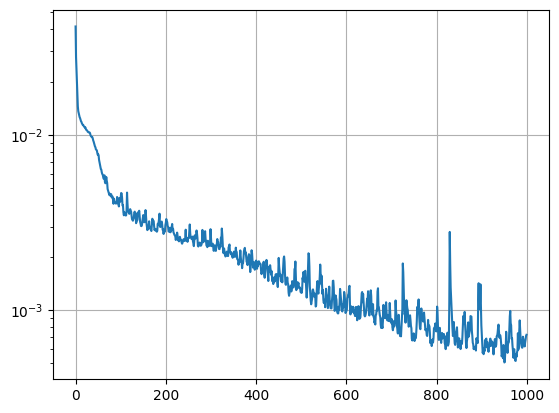

In [116]:
plt.semilogy(loss)
plt.grid()

In [117]:
n = 500
t = np.linspace(t0, tfinal, n)

A_data = np.random.uniform(-1.0, 1.0, size=(1,))
F_data = np.random.uniform(-1.0, 1.0, size=(1,))
G_data = np.random.uniform(-1.0, 1.0, size=(1,))
E_data = (1/4)*((A_data**2/l**2) + (F_data**2/k**2) + (2*(G_data**2)/(k**2 + l**2)))
V_data = (1/2)*(A_data**2 + F_data**2 + 2*(G_data**2))

init_data_rk = np.column_stack((A_data, F_data, G_data))
init_data_rk = np.squeeze(init_data_rk)

init_data_model = np.column_stack((A_data, F_data, G_data, E_data, V_data))
init_data_model = np.squeeze(init_data_model)
print(init_data_model.shape)

z = np.repeat(np.expand_dims(init_data_model, axis=0), len(t), axis=0)
print(z.shape)

(5,)
(500, 5)


In [118]:
sol_rk = odeint(Lorenz1960, init_data_rk, t)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk = (1/4)*((A_rk**2/l**2) + (F_rk**2/k**2) + (2*(G_rk**2)/(k**2 + l**2)))
V_rk = (1/2)*(A_rk**2 + F_rk**2 + 2*(G_rk**2))

In [119]:
A_model = jax.vmap(var_model, [0, 0, None, None])(t, z, 0, params)
F_model = jax.vmap(var_model, [0, 0, None, None])(t, z, 1, params)
G_model = jax.vmap(var_model, [0, 0, None, None])(t, z, 2, params)
E_model = (1/4)*((A_model**2/l**2) + (F_model**2/k**2) + (2*(G_model**2)/(k**2 + l**2)))
V_model = (1/2)*(A_model**2 + F_model**2 + 2*(G_model**2))

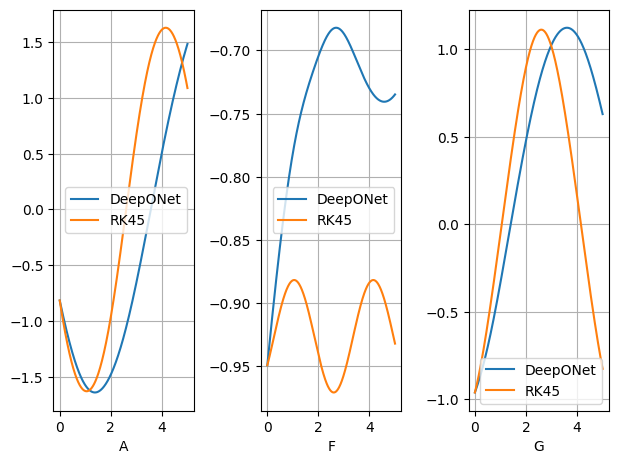

In [120]:
fig = plt.figure()

plt.subplot(1, 3, 1)
plt.tight_layout()
plt.plot(t, A_model)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 2)
plt.tight_layout()
plt.plot(t, F_model)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 3)
plt.tight_layout()
plt.plot(t, G_model)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.show()

In [121]:
AFG_vals = jnp.column_stack((A_model, F_model, G_model))
E_vals = z[:, 3:4]
V_vals = z[:, 4:]

print(type(AFG_vals), AFG_vals.shape)
print(type(E_vals), E_vals.shape)
print(type(V_vals), V_vals.shape)

<class 'jaxlib.xla_extension.ArrayImpl'> (500, 3)
<class 'numpy.ndarray'> (500, 1)
<class 'numpy.ndarray'> (500, 1)


In [122]:
def obj_function_E(x, E_0) :

    A, F, G = x
    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    E_err = (E-E_0)**2

    return E_err[0]


def obj_function_V(x, V_0) :
    
    A, F, G = x
    V = (1/2)*(A**2 + F**2 + 2*(G**2))
    V_err = (V-V_0)**2

    return V_err[0]

def obj_function_E_V(x, E_0, V_0) :

    factor = E_0/V_0
    
    # factor = jnp.rint(jnp.log10(E_0/V_0))
    
    A, F, G = x
    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    E_err = (E-E_0)**2
    V_err = (V-V_0)**2

    # err_total = E_err + (10**factor)*V_err

    err_total = E_err + factor*V_err

    return err_total[0]

In [123]:
def find_min_E(x, E_0):

    return minimize(obj_function_E, x, (E_0,), method='BFGS', tol = 1e-6)


def find_min_V(x, V_0):

    return minimize(obj_function_V, x, (V_0,), method='BFGS', tol = 1e-6)


def find_min_E_V(x, E_0, V_0):

    return minimize(obj_function_E_V, x, (E_0, V_0), method='BFGS', tol = 1e-7)

In [124]:
# result_E = jax.vmap(find_min, (0, 0), 0)(AFG_vals, E_vals)
# result_E = result_E.x

# result_V = jax.vmap(find_min_V, (0, 0), 0)(AFG_vals, V_vals)
# result_V = result_V.x

result_E_V = jax.vmap(find_min_E_V, (0, 0, 0), 0)(AFG_vals, E_vals, V_vals)
result_E_V = result_E_V.x

result_final = result_E_V

print(result_final.shape)

(500, 3)


In [125]:
A_final = result_final[:, 0]
F_final = result_final[:, 1]
G_final = result_final[:, 2]
E_final = (1/4)*((A_final**2/l**2) + (F_final**2/k**2) + (2*(G_final**2)/(k**2 + l**2)))
V_final = (1/2)*(A_final**2 + F_final**2 + 2*(G_final**2))

print(A_final.shape, F_final.shape, G_final.shape, E_final.shape, V_final.shape)

(500,) (500,) (500,) (500,) (500,)


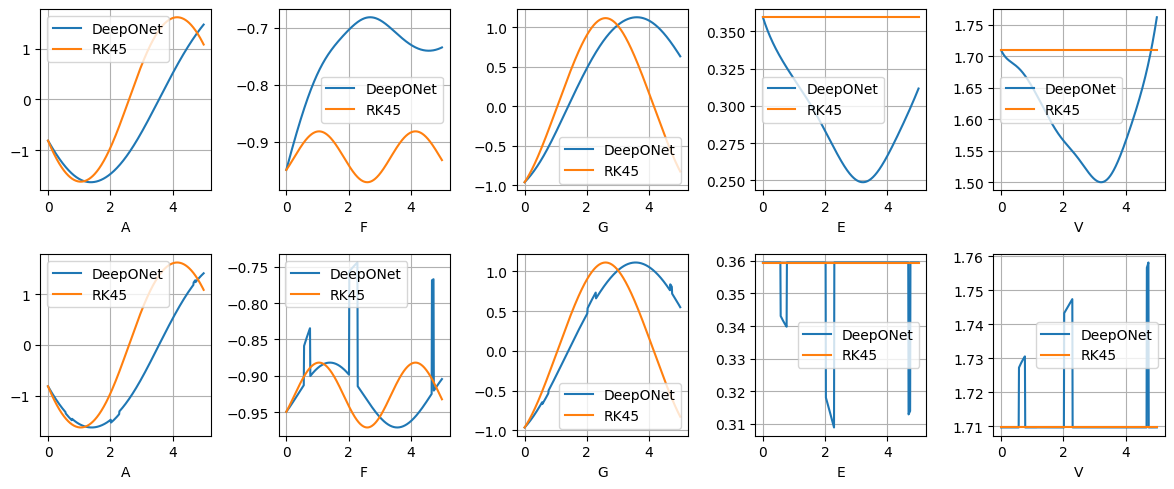

In [126]:
fig = plt.figure(figsize=(12, 5))

plt.subplot(2, 5, 1)
plt.tight_layout()
plt.plot(t, A_model)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 2)
plt.tight_layout()
plt.plot(t, F_model)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 3)
plt.tight_layout()
plt.plot(t, G_model)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 4)
plt.tight_layout()
plt.plot(t, E_model)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(2, 5, 5)
plt.tight_layout()
plt.plot(t, V_model)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 6)
plt.tight_layout()
plt.plot(t, A_final)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 7)
plt.tight_layout()
plt.plot(t, F_final)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 8)
plt.tight_layout()
plt.plot(t, G_final)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 9)
plt.tight_layout()
plt.plot(t, E_final)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(2, 5, 10)
plt.tight_layout()
plt.plot(t, V_final)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.show()

In [127]:
@jax.jit
def deriv_D(x, A_init, F_init, G_init, E_0, V_0) :

    factor = E_0/V_0
    factor = 1.0

    A = x[0]
    F = x[1]
    G = x[2]

    dE_dA = A/(2*(l**2))
    dE_dF = F/(2*(k**2))
    dE_dG = G/(k**2 + l**2)

    dV_dA = A
    dV_dF = F
    dV_dG = 2*G
  
    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    dD_dA = 10*(A-A_init) + 2*(E-E_0)*dE_dA + 2*factor*(V-V_0)*dV_dA
    dD_dF = 10*(F-F_init) + 2*(E-E_0)*dE_dF + 2*factor*(V-V_0)*dV_dF
    dD_dG = 10*(G-G_init) + 2*(E-E_0)*dE_dG + 2*factor*(V-V_0)*dV_dG

    deriv_D_arr = jnp.array([dD_dA, dD_dF, dD_dG])

    return deriv_D_arr


In [128]:
@jax.jit
def func_D(x, A_init, F_init, G_init, E_0, V_0) :

    factor = E_0/V_0
    factor = 1.0
    
    A = x[0]
    F = x[1]
    G = x[2]
    
    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    # print("E", E)
    # print("E_0", E_0)
    # print("V", V)
    # print("V_0", V_0)

    D = 5*((A-A_init)**2) + 5*((F-F_init)**2) + 5*((G-G_init)**2) + (E-E_0)**2 + factor*(V-V_0)**2

    D_arr = jnp.array([D])

    return D_arr

In [129]:
@jax.jit
def find_rec(x):
    # y = jnp.where(x == 0.0, 1.0, x)
    # ans = jnp.where(x == 0.0, 0.0, 1/y)
    # ans = jnp.reshape(ans, (-1,))[0]
    x = x + jnp.finfo(jnp.float64).eps
    return 1/x

In [130]:
# test = jnp.array([[0.0]])
# print(find_rec(test))

# grad_rec=jax.grad(find_rec)
# print(grad_rec(test))


In [131]:
@jax.jit
def BFGS(x, E_0, V_0) :

    # print("HERE")

    # print(x.shape, E_0.shape, V_0.shape)

    # input()
    x_0 = x
    x_0 = jnp.reshape(x_0, (-1, 1))
    
    x_init = jnp.copy(x_0)
    
    A_init = x_init[0]
    F_init = x_init[1]
    G_init = x_init[2]
    E_init = (1/4)*((A_init**2/l**2) + (F_init**2/k**2) + (2*(G_init**2)/(k**2 + l**2)))
    V_init = (1/2)*(A_init**2 + F_init**2 + 2*(G_init**2))

    x_0 = 0.95*x_0

    iter = 0
    I_3 = jnp.identity(3)
    
    B_0_inv = jnp.identity(3)


    D_0 = func_D(x_0, A_init, F_init, G_init, E_0, V_0)
    gradD_0 = deriv_D(x_0, A_init, F_init, G_init, E_0, V_0)

    x_1 = x_0 - B_0_inv@gradD_0

    
    while iter < 5:

        delta_x = x_1 - x_0

        D_1 = func_D(x_1, A_init, F_init, G_init, E_0, V_0)
        # print("D_1", D_1)
        gradD_1 = deriv_D(x_1, A_init, F_init, G_init, E_0, V_0)

        y = gradD_1 - gradD_0       

        y_T_delta_x = y.T@delta_x
        # y_T_delta_x = jnp.where(y_T_delta_x > 0., y_T_delta_x, 1e-30)
        # y_T_delta_x_rec = 1/y_T_delta_x
        y_T_delta_x_rec = find_rec(y_T_delta_x)
        
        
        # print("y_T_delta_x", y_T_delta_x)
        
        B_1_inv = ((I_3 - (y_T_delta_x_rec*(delta_x@y.T)))@B_0_inv@(I_3 - (y_T_delta_x_rec*(y@delta_x.T)))) + (y_T_delta_x_rec*(delta_x@delta_x.T))

        # B_1_inv = ((I_3 - (delta_x@y.T/y.T@delta_x))@B_0_inv@(I_3 - (y@delta_x.T/y.T@delta_x))) + (delta_x@delta_x.T/y.T@delta_x)

        # print("B_1_inv", B_1_inv)

        x_next = x_1 - B_1_inv@gradD_1

        # print("Bx_next", x_next)

        x_0 = x_1
        x_1 = x_next

        D_0 = D_1
        gradD_0 = gradD_1

        B_0_inv = B_1_inv
        
        iter = iter + 1


    A = x_1[0]
    F = x_1[1]
    G = x_1[2]

    A = jnp.reshape(A, (-1, ))[0]
    F = jnp.reshape(F, (-1, ))[0]
    G = jnp.reshape(G, (-1, ))[0]

    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    A_init_A = jnp.column_stack((A_init, A))
    F_init_F = jnp.column_stack((F_init, F))
    G_init_G = jnp.column_stack((G_init, G))
    
    E_init_E_E_0 = jnp.column_stack((E_init, E, E_0))
    V_init_V_V_0 = jnp.column_stack((V_init, V, V_0))
    
    # print("A", A)
    # print("F", F)
    # print("G", G)

    # print("COMPARE A", A_init_A)
    # print("COMPARE F", F_init_F)
    # print("COMPARE G", G_init_G)

    # print("COMPARE E", E_init_E_E_0)
    # print("COMPARE V", V_init_V_V_0)

    
    # input()

    return A, F, G

In [132]:
# AFG_test = jnp.array([0.2000001, 1.2, 0.9])
# E_test = jnp.array([1.4])
# V_test = jnp.array([0.8])

# print(AFG_test.shape, E_test.shape, V_test.shape)

# A, F, G = BFGS(AFG_test, E_test, V_test)
# print(A, F, G)

# result = minimize(func_D, AFG_test, (E_test, V_test), method='BFGS', tol = 1e-6)
# A_true, F_true, G_true = result.x
# print(A_true, F_true, G_true)

In [133]:
@jax.jit
def find_min_E_V(AFG_list, E_0, V_0) :

    A = AFG_list[0]
    F = AFG_list[1]
    G = AFG_list[2]

    x = jnp.column_stack((A, F, G))  

    return jax.vmap(BFGS, (0, 0, 0), 0)(x, E_0, V_0)

In [134]:
class ClosestPoint(nn.Module):

    E_0: float
    V_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        A, F, G = find_min_E_V(inputs, self.E_0, self.V_0)
    
        return A, F, G

In [135]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]


    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)


    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]
    # E_tr = trunk_net[:,3*self.units:4*self.units]
    # V_tr = trunk_net[:,4*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]
    # E_br = branch_net[:,3*self.units:4*self.units]
    # V_br = branch_net[:,4*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    A, F, G = ClosestPoint(E_0, V_0)([A, F, G])

    # print("----------------------------------------------------------------------------------------")
    # print("AFG", A, F, G)
    # print("----------------------------------------------------------------------------------------")
      
    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    # input()
    return A, F, G

In [136]:
@partial(jax.jit, static_argnums=(2,))
def Cvar_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Cvar(t, z, component, params):
  return jax.vmap(Cvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Cvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Cvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Closs(params, t, z):
    
    A_t_loss_w = 1.0
    F_t_loss_w = 1.0
    G_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 0.0
    V_loss_w = 0.0
    
    E_0_val = z[:, -2]
    V_0_val = z[:, -1]
    
    A_val = Cvar(t, z, 0, params)
    F_val = Cvar(t, z, 1, params)
    G_val = Cvar(t, z, 2, params)
    
    
    E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
    E_loss = E_val - E_0_val
    E_loss = jnp.square(E_loss)
    E_loss = jnp.mean(E_loss)
    
    
    V_val = (0.5)*(A_val**2 + F_val**2 + 2*(G_val**2))
    V_loss = V_val - V_0_val
    V_loss = jnp.square(V_loss)
    V_loss = jnp.mean(V_loss)
    
    
    A_t_val = Cvar_t(t, z, 0, params)  
    F_t_val = Cvar_t(t, z, 1, params)
    G_t_val = Cvar_t(t, z, 2, params)
    
    # mask_A = jnp.isnan(A_val)
    # mask_F = jnp.isnan(F_val)
    # mask_G = jnp.isnan(G_val)
    # mask_A_t = jnp.isnan(A_t_val)
    # mask_F_t = jnp.isnan(F_t_val)
    # mask_G_t = jnp.isnan(G_t_val)    
    
    
    # mask_net = jnp.logical_or(mask_A, mask_F)
    # mask_net = jnp.logical_or(mask_net, mask_G)
    # mask_net = jnp.logical_or(mask_net, mask_A_t)
    # mask_net = jnp.logical_or(mask_net, mask_F_t)
    # mask_net = jnp.logical_or(mask_net, mask_G_t)
    
      
    # A_val = jnp.where(mask_net, 0., A_val)
    # F_val = jnp.where(mask_net, 0., F_val)
    # G_val = jnp.where(mask_net, 0., G_val)
    # A_t_val = jnp.where(mask_net, 0., A_t_val)
    # F_t_val = jnp.where(mask_net, 0., F_t_val)
    # G_t_val = jnp.where(mask_net, 0., G_t_val)
        
    
    
    # print("AFG VALS", A_val, F_val, G_val)
    # print("AFG_T VALS", A_t_val, F_t_val, G_t_val)

    # input()
    
    A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
    A_t_loss = jnp.square(A_t_loss)
    A_t_loss = jnp.mean(A_t_loss)
    
    F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
    F_t_loss = jnp.square(F_t_loss)
    F_t_loss = jnp.mean(F_t_loss)
    
    G_t_loss = G_t_val + (0.25)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
    G_t_loss = jnp.square(G_t_loss)
    G_t_loss = jnp.mean(G_t_loss)
    
    diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss
    
    final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss

    # print("AT LOSS", A_t_loss)
    # print("FT LOSS", F_t_loss)
    # print("GT LOSS", G_t_loss)
    # print("FINAL LOSS", final_loss)

    # input()

    return final_loss

@jax.jit
def Ctrain_step(params, pdes, z):
  t = pdes[:,0]
    
  return jax.value_and_grad(Closs)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def Coptimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [137]:
def Ctrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-4
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    
    batch_no = 0

    for i in range(epochs):

    # print("EPOCH NUMBER", i)

        # input()
    # batch_no = 0

        # input()

        for (des_batch, z_batch) in ds:
    
            # print("BATCH NUMBER", batch_no)
            # print("PARAMS", params)
    
            batch_no = batch_no + 1
    
            # input()   
    
            loss, grads = Ctrain_step(params, des_batch.numpy(), z_batch.numpy())
            # print("LOSS", loss)
            # input()
            params, opt_state = Coptimize(grads, opt_state, params, optimizer.update)
            
            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [138]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0)
u_init = jnp.full((10, 5), 1.0)

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [139]:
Cparam_count = sum(x.size for x in jax.tree.leaves(Cparams))
print(Cparam_count)

16640


In [140]:
Cparams = copy.deepcopy(params)

In [141]:
epochs = 1000
Cparams, Closs = Ctrain_network(Cparams, de_points, sensors, epochs)

batch size: 100
Loss in epoch 0: 0.025087510506568888
Loss in epoch 100: 0.002447444164096271
Loss in epoch 200: 0.18568695114083753
Loss in epoch 300: 0.06436855872784218
Loss in epoch 400: 0.0421967887881086
Loss in epoch 500: 0.035651303812558516
Loss in epoch 600: 0.9118987161723576
Loss in epoch 700: 0.4660260364909599
Loss in epoch 800: 0.37047120480725304
Loss in epoch 900: 180.29666332449418


In [142]:
# # AFG VALS 

# A = np.array([ 2.21362187e-01,  9.11715341e-01,  1.11092159e+00,  8.05259087e-01,
#     5.47689259e-01,  3.34106120e-01, -2.46542585e-01,  9.37814517e-01,
#    -8.69553353e-01,  9.32844304e-01, -1.17418241e+00, -1.89862071e+00,
#    -6.14075994e-01,  8.95443753e-02, -5.48297185e-01, -4.66887446e-01,
#     1.32971013e+00, -7.54506067e-01, -1.26607257e+00,  7.89672094e-01,
#    -7.39488680e-01, -5.02611091e-01, -7.98506339e-01,  7.83595455e-02,
#    -1.43141308e-01, -4.61085531e-01,  1.17565714e-01, -5.80690744e-02,
#    -5.86632692e-02, -4.44860802e-01, -1.72510697e-01,  5.94446437e-02,
#    -8.31129730e-04, -6.61487726e-04, -2.14578512e-01,  5.26787395e-02,
#    -1.11249231e+00, -1.03514201e+00, -9.79033719e-01, -3.27012427e-01,
#     2.82265963e-01, -6.96985510e-01,  1.55468933e+00, -5.54865388e-01,
#    -6.23012424e-01, -7.10405416e-01,  1.33134200e+00,  1.11947114e+00,
#    -1.89839689e-01,  3.43398317e-01,  9.04464977e-02,  5.12394008e-01,
#     4.44847075e-03, -1.61360417e+00,  1.33161076e+00,  3.16966858e-01,
#    -8.93643020e-01,  1.08477588e+00,  1.78257935e-02,  6.96216187e-01,
#     2.89780734e-01,  1.19524267e-01,  1.06712841e-01,  4.85593345e-02,
#    -1.47300114e+00, -1.43904928e+00, -5.09625448e-02,  1.37858888e+00,
#     1.20382502e+00, -2.31704642e-01, -9.78446356e-01, -7.58701778e-01,
#     1.58780404e-01, -1.12776442e+00, -1.51914780e-02, -1.30831020e+00,
#    -1.55264971e+00, -7.72235259e-01, -6.47551583e-01, -1.19951723e-01,
#    -3.39524001e-01,  3.24769089e+00, -1.17850288e+00, -1.44661469e+00,
#    -2.94121955e-02, -6.27661827e-01,  3.84697368e-01,  1.06394547e+00,
#    -6.21892132e-01,  6.24965546e-01,  6.75259994e-01,  2.25729149e-02,
#    -8.61783122e-01, -7.45089568e-01,  1.00340671e+00, -7.95686168e-01,
#     5.74135595e-01,  1.11399714e+00,  4.01262359e-01,  2.18324527e-02],      dtype=np.float64)

# F = np.array([ 9.04330880e-01, -6.05121079e-01,  8.53414272e-01, -6.62120648e-01,
#    -6.54846531e-01,  3.63055632e-01,  3.01049630e+00, -1.17959578e-02,
#     6.00208851e-01, -2.34875340e-01,  1.83257513e-01,  1.97112974e+00,
#     5.25596824e-01, -3.10760057e-01,  5.12831543e-01,  9.12698992e-01,
#     1.53031610e-01, -7.54055043e-01,  3.75356462e-01, -6.12660821e-01,
#     3.17355638e-01, -6.08791459e-01,  4.93122624e+00,  3.44825911e-01,
#     3.31033010e-01, -1.58163453e-01, -8.70669287e-03, -8.59081203e-01,
#    -1.27641008e-01,  8.98091388e-01,  4.86697413e-01, -2.45725669e+00,
#    -1.61443599e-01, -1.75375493e-01, -1.59368378e-01, -7.25540481e-02,
#     3.93165347e-01, -7.86656943e-01, -6.22315760e-01,  9.81597366e-01,
#     3.51627819e-01, -5.81007052e-03, -2.12569080e-01,  5.27246463e-02,
#     5.65813590e-02, -2.65972389e-01,  7.76411326e-01, -3.84778669e-01,
#     5.10161409e-01,  6.95854163e-01, -1.12833414e-01,  2.81172777e-01,
#    -2.99252867e-02,  3.34342983e-01,  2.54053825e-01, -9.48937494e-01,
#     1.97132689e+01,  5.83551222e-01,  1.22054293e+00,  6.60656685e-01,
#     6.23381415e-01, -3.27553367e-01, -1.11703157e-01, -2.47925067e-03,
#     9.19358892e-01,  6.65872753e-01,  5.66303463e-01, -5.56302655e-01,
#    -8.01140440e-01, -1.27590742e+00, -7.65908094e-01,  4.66903311e-01,
#    -3.85229052e-01,  7.08216721e-01, -1.10274496e-02,  6.62770202e-02,
#    -5.80330768e-01,  7.69970284e-02,  5.23342785e-01,  2.54540039e-01,
#     8.26333385e-01,  3.05367668e+01,  7.54286191e-01, -5.70205566e-01,
#     1.92045819e-02,  1.75847622e-01, -4.99162653e-01,  7.70123817e-01,
#    -6.42204718e-01,  6.36804455e-01, -5.73978732e-02,  9.94331637e-01,
#     5.94521507e-01, -1.64883385e-01, -8.10495649e-01,  7.06796912e-01,
#    -1.00641727e-01,  4.44707144e-01, -2.28744080e-02, -2.02423431e-01],      dtype=np.float64)

# G = np.array([ 1.72938127e-01,  2.71370055e-01, -5.03076315e-01, -2.75746886e-02,
#     4.17655476e-02,  4.11154958e-01, -2.21013425e+00,  1.58653031e-01,
#    -1.50977853e+00,  3.26342521e-01, -8.79933123e-03, -2.06489803e+00,
#    -6.08534258e-01, -3.84407819e-01,  9.06358823e-02, -2.48613845e-01,
#    -5.82579165e-02, -5.54585211e-01, -5.44076037e-01, -7.13135749e-01,
#    -2.62837644e-01,  7.15228427e-03, -2.49280491e+00, -5.47901047e-01,
#    -4.27387144e-01, -3.28496307e-01,  2.79569422e-01,  9.63904074e-01,
#     1.55754359e-01,  8.04175110e-03,  2.35303723e-01, -1.17735850e+00,
#    -9.71869122e-01, -9.06077739e-01, -9.08859877e-01, -3.78151420e-01,
#     7.30868618e-02, -3.59699796e-02, -7.88342354e-01,  3.70311058e-01,
#    -6.33631318e-01, -5.85656051e-01,  3.76745666e-02, -5.30353097e-01,
#    -7.94162178e-01, -5.28154976e-01,  1.37917467e-03, -4.53665084e-01,
#     5.41850397e-01,  2.64746094e-01, -5.88975257e-01,  3.43097640e-01,
#     2.63764126e-02, -1.26237256e+00, -4.36861949e-01,  6.09534575e-02,
#    -4.45938847e+00,  7.63907728e-01,  2.11339238e-03,  2.01445341e-01,
#    -6.03125554e-01, -9.11375848e-01,  9.39105204e-01,  2.99150978e-02,
#    -1.33201214e+00,  2.64419244e-02, -6.46495038e-01,  8.79730559e-01,
#     9.69942523e-02, -2.10601180e-02, -6.07402570e-01, -5.03996408e-03,
#    -6.51367003e-01, -1.01825903e+00,  4.21278171e-03, -1.04643084e+00,
#     1.63010306e-01,  7.82992599e-01, -5.15070338e-01, -1.93223743e-01,
#    -1.98842723e-01, -3.95851383e+00,  4.14942612e-01, -1.96714213e-01,
#     1.08043759e-01,  4.27634555e-01,  4.87613397e-01,  2.73410568e-01,
#    -5.00893262e-01, -6.39718189e-01, -7.55622204e-01,  7.68196774e-01,
#    -8.00450785e-01, -7.65209328e-01,  8.25583260e-02, -3.13852126e-01,
#    -1.69717186e-01, -2.74375656e-01, -9.13366377e-01, -8.75035143e-01],      dtype=np.float64)


# # AFG_T VALS 

# A_t = np.array([-5.34548839e-01,  4.24830669e-01, -2.62537147e+01,  1.49859917e-02,
#     1.21011652e-01, -4.91045303e-01,  6.48376262e-01,  2.39647828e-02,
#     7.27832763e-02,  2.99750297e-01,  1.51597875e+00, -9.29421648e-01,
#    -4.18753662e+00,  1.80031463e-01, -1.38706503e-01,  1.66290925e-01,
#     9.76077387e-03,  5.47800998e-02,  6.06406272e-02, -6.66509715e-01,
#     1.23568499e-01, -6.89291993e-03,  3.25142845e-01,  2.41867481e-01,
#     2.16948784e-01,  4.22754397e-03, -1.30792389e+04,  1.56436132e+00,
#     1.27753275e+00, -5.15548397e-01, -3.55739355e-01, -2.55446806e+00,
#    -1.65780324e+03, -1.14944986e-01, -4.11359103e-02, -1.30293362e-01,
#     1.22969640e-02,  1.42446168e-01, -4.35763055e-01, -9.87798333e-01,
#     3.85723384e-01,  8.82258523e-02,  2.76268919e-02,  1.91748099e-01,
#     7.53992417e-02, -4.62192365e-02, -3.83577930e-02, -1.07082181e+00,
#    -2.53403943e+00, -2.16242044e+00, -6.12396390e-02,  1.65035932e-02,
#    -1.21354030e-02,  2.47977955e-02,  2.34954798e-01,  2.65359321e-01,
#     6.05081905e+00, -1.20683120e+00, -1.17889588e+00, -1.04903133e-01,
#     7.60069451e-01, -1.24498279e+00, -1.27262831e+01, -4.36947877e+00,
#    -2.15427581e-01, -3.31785502e-02,  5.57507964e-02,  4.83470126e-01,
#     9.14054155e-01,  1.41551785e+00,  2.03298166e-01,  1.55024062e-01,
#    -3.56266983e-01, -2.82897930e-01,  8.75798353e-01, -2.92719372e-01,
#    -3.27891067e-01, -2.18945383e-01, -8.56753849e-02,  2.65623528e-01,
#     7.73032169e-01, -3.20339319e+00, -9.92267055e+00, -2.69570065e-01,
#    -1.62806056e+00, -4.23518596e-01, -4.41611529e-01, -5.17878489e-01,
#    -8.16483127e-02,  4.83295130e-01, -2.70071138e-01, -1.62825861e+00,
#    -1.21529572e+01, -9.91463795e-03,  6.82754037e+00,  4.12594391e-01,
#     5.06733590e-02,  2.47952959e-01, -8.23467618e-02, -2.96674615e-01],      dtype=np.float64)

# F_t = np.array([-9.26014457e-02,  2.53768540e-01, -1.23575505e+01,  3.54532491e-03,
#     2.21659039e-01,  6.16218374e-02, -1.12923800e+01,  2.26868067e-02,
#     2.13352965e-01,  1.04153125e-01, -8.68862752e-02,  2.76110553e+00,
#     1.23781455e+00,  1.36742054e-01, -7.55483188e-02,  4.65346662e-02,
#    -3.24067321e-02, -1.17320626e-01,  1.40459290e-01, -9.96846098e-02,
#     1.90864403e-02,  9.57911369e-03, -9.40174003e+00,  1.71686575e-02,
#     3.74705225e-02, -6.06406546e-02,  8.44888669e+03,  4.30178983e+00,
#     2.91885114e+00, -4.11036065e-01, -3.05874225e-02,  5.82403995e+01,
#     6.04400598e+02,  8.21780718e+00,  5.30377374e-01, -5.44350225e-02,
#     8.82568375e-02, -1.84826820e-01,  4.46722623e-02, -1.48265021e-02,
#     4.26991093e-02,  1.26549081e-02,  2.05545144e-02, -6.39795895e-02,
#     9.12543779e-03, -6.15457552e-02,  2.88154630e-02,  3.43570134e-01,
#     3.25444312e+00,  3.76080006e+00,  6.67385688e-02, -2.73351566e-01,
#     3.00908314e-02, -2.36397324e-02, -2.47182237e-02,  2.54109524e-03,
#     3.74748415e+01,  1.36245401e-01, -1.60012547e+00, -7.35310817e-02,
#     5.48989212e-02,  2.31330455e+00,  1.33770819e+01,  3.42007998e-01,
#     3.45068035e-01, -8.21608003e-01,  1.08757200e+00, -6.58242128e-02,
#     4.46964342e-01, -2.78131237e-01, -1.02971853e+00,  2.62784209e-01,
#     4.42347367e-01,  1.30060707e+00,  5.95515226e-01, -1.86782930e-01,
#     2.95870415e-01,  6.96845941e-02, -1.60986349e+00,  1.06712597e-01,
#     2.32319827e-01, -2.91316715e+01,  2.50301605e+00, -8.47896517e-02,
#     9.29178249e-01, -7.38828705e-03,  6.08141895e-01,  3.62296621e-02,
#    -3.32586799e-02,  1.51351854e-02, -8.77524136e-02,  3.99161096e-03,
#     5.19606520e+01,  2.26235300e-01,  2.45630627e+00, -7.79815056e-03,
#     1.31577986e-01, -1.36592701e-01, -3.53452367e-02,  2.50049709e-03],      dtype=np.float64)

# G_t = np.array([ 6.60136734e-01, -4.88056029e-01, -2.98764083e+01, -3.00248398e-02,
#    -4.25102448e-01,  1.75218646e-01,  1.93157012e+00, -7.01061764e-02,
#    -1.36575184e-01, -3.93814996e-01, -7.03573286e-01, -1.27520891e+00,
#    -1.08632488e+00, -3.57047370e-02, -2.03109883e-01, -2.78283691e-02,
#     6.84392286e-02, -7.06819119e-03, -1.84306421e-02, -3.38234803e-01,
#    -1.62351305e-01, -3.45364619e-02,  1.27672483e+00,  2.44872208e-02,
#    -2.39098779e-02,  9.66505806e-03,  4.86538057e+03, -5.07928503e+00,
#     2.48982480e-01,  8.07750536e-02, -7.19368487e-02,  4.27417367e+01,
#    -4.10122236e+02, -9.41050824e-01, -4.40107556e-02, -3.95979214e-03,
#    -1.60585334e-01,  8.79344211e-02,  2.50271697e-01, -4.05189165e-01,
#     9.81170776e-02, -5.27075438e-02, -3.37520343e-01, -1.06716387e-01,
#    -2.98507658e-02,  4.56830063e-02,  1.09272997e+00, -1.86344638e+00,
#    -8.44945617e-01, -7.28319461e+00, -2.08784019e-01,  3.75738527e-02,
#     5.16262138e-02, -9.81561070e-02,  3.50307420e-01, -6.42355880e-01,
#    -9.23390185e-01,  7.69944184e-01, -6.31162104e+00,  2.57753166e-01,
#     2.15284728e-01,  1.42920012e+00, -2.45824771e+01, -1.51710788e+00,
#    -4.13798236e-01, -4.79911810e+00, -6.88162105e-01, -6.66922450e-01,
#    -3.64131964e+00,  1.09505952e-01,  4.27339376e-01, -2.32566882e-01,
#    -1.91900064e-01, -1.25917164e+00, -3.07495768e+00, -4.45304903e-01,
#    -1.55814786e+00, -1.13880574e-01,  3.51188994e+00, -1.11342981e-01,
#    -2.14409766e-01,  1.10132860e+00, -1.76265885e+01,  1.12891157e+00,
#     3.16428672e+00, -3.08977666e-01,  4.86596500e-01,  9.37889993e-01,
#     6.35544649e-02,  2.37571416e-01, -1.18255455e-01,  1.96652980e-02,
#     2.10487619e+01, -1.95516260e-02,  1.60755857e+01, -5.23632190e-01,
#     5.61199463e-02,  3.74381700e-01, -1.76821712e-02, -4.68405026e-03], dtype=np.float64)

# # AT LOSS Traced<ConcreteArray(1738726.4951146268, dtype=float64)>with<JVPTrace(level=2/0)> with
# # FT LOSS Traced<ConcreteArray(717578.7492961254, dtype=float64)>with<JVPTrace(level=2/0)> with
# # GT LOSS Traced<ConcreteArray(238460.50377759206, dtype=float64)>with<JVPTrace(level=2/0)> with
# # LOSS 2694765.7481883443

In [143]:
# A_max = np.max(A)
# F_max = np.max(F)
# G_max = np.max(G)

# A_t_max = np.max(A_t)
# F_t_max = np.max(F_t)
# G_t_max = np.max(G_t)

# print(A_max, F_max, G_max)
# print(A_t_max, F_t_max, G_t_max)

# print(A.argmax(axis=0))
# print(F.argmax(axis=0))
# print(G.argmax(axis=0))

# print(A_t.argmax(axis=0))
# print(F_t.argmax(axis=0))
# print(G_t.argmax(axis=0))

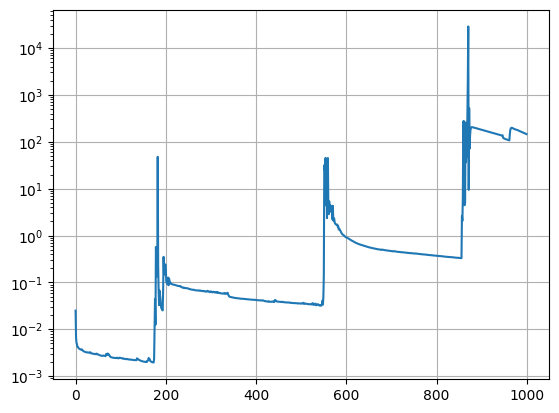

In [144]:
plt.semilogy(Closs)
plt.grid()

In [145]:
A = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 0, Cparams)
F = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 1, Cparams)
G = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 2, Cparams)
E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
V = (1/2)*(A**2 + F**2 + 2*(G**2))

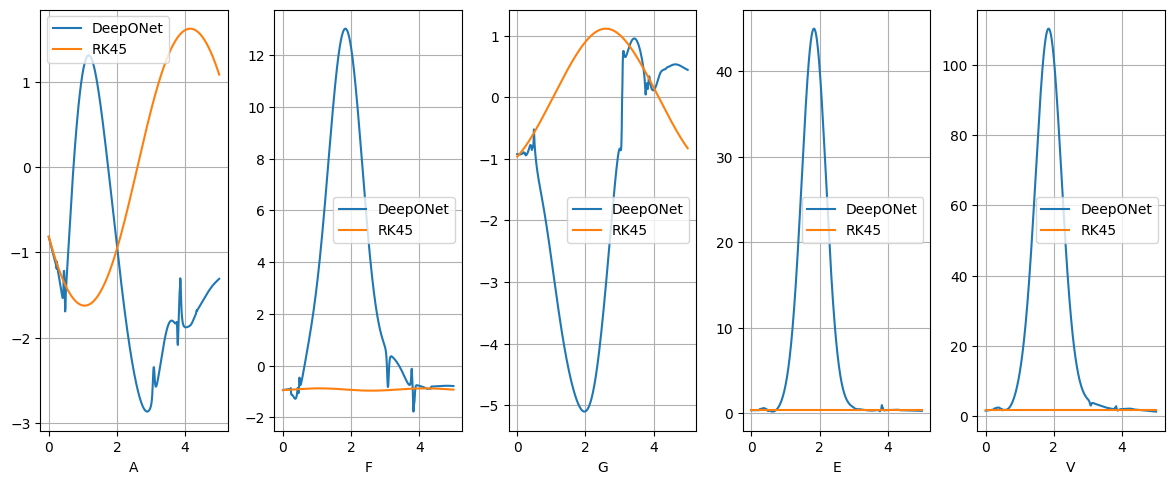

In [146]:
fig = plt.figure(figsize=(12, 5))

plt.subplot(1, 5, 1)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 5, 2)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 5, 3)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 5, 4)
plt.tight_layout()
plt.plot(t, E)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 5, 5)
plt.tight_layout()
plt.plot(t, V)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.show()
